In [19]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

**Reading the data**

In [20]:
df =pd.read_csv('data/data_1.csv',header=None,names=['feature','target'])
df

,feature,target
0,1651.000000,432.645217
1,1691.816327,454.935530
2,1732.632653,471.525248
3,1773.448980,482.506389
4,1814.265306,468.357886
5,1855.081633,482.152531
6,1895.897959,540.021756
7,1936.714286,534.584267
8,1977.530612,558.346208
9,2018.346939,566.423445


**extracting the feature and target datas**

In [21]:
X=np.array(df[['feature']])
Y= np.array(df['target'])

**Splitting the datasets into train,cross_validation and test**

In [22]:
X_train,X_,Y_train,Y_ = train_test_split(X,Y,test_size=0.40,random_state=1)
X_cv,X_test,Y_cv,Y_test = train_test_split(X_,Y_,test_size=0.50,random_state=1)
del X_,Y_  #deleting the temporary variable
print(f'The number of training data set is: {X_train.shape[0]}')
print(f'The number of cross validation data set is: {X_cv.shape[0]}')
print(f'The number of test data set is: {X_test.shape[0]}')

The number of training data set is: 30
The number of cross validation data set is: 10
The number of test data set is: 10


**Plot of the given data**

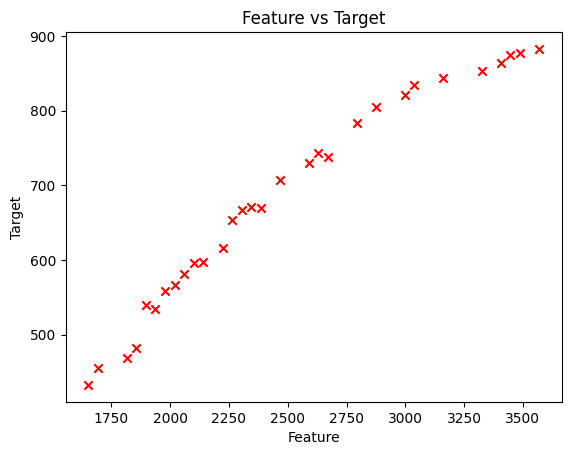

In [23]:
plt.scatter(X_train,Y_train,marker='x',c='r')
plt.title('Feature vs Target')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.show()

**Scaling the input feature**

In [24]:
linear_scaler = StandardScaler()
X_train_scaled = linear_scaler.fit_transform(X_train)
print(f'The mean of the training data is {linear_scaler.mean_.squeeze():.2f}')
print(f'The standard deviation of the training data is {linear_scaler.scale_.squeeze():.2f}')

The mean of the training data is 2504.06
The standard deviation of the training data is 574.85


**Training the model**

In [25]:
lr = LinearRegression()
lr.fit(X_train_scaled,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Now we are evaluating the model's performance through the cost function of cross_validation dataset**

In [26]:
X_cv_scaled = linear_scaler.transform(X_cv)
predicted_cv = lr.predict(X_cv_scaled)
print(f'The cost function of the cross_validation dataset is: {mean_squared_error(predicted_cv,Y_cv)/2}')

The cost function of the cross_validation dataset is: 551.7789026952212


**As we can observe from the plot above that the straight linear model cannot fit the prediction efficiently, so we are doing some polynomial feature engineering**

In [30]:
pf = PolynomialFeatures(degree=2,include_bias = False)
X_mapped=pf.fit_transform(X_train)  #converting the training data into 2 degree polynomial expression
linear_scaler = StandardScaler()
X_mapped_scaled = linear_scaler.fit_transform(X_mapped)


**Training the model with the scaled polynomial expression**

In [28]:
lr = LinearRegression()
lr.fit(X_mapped_scaled,Y_train)  #
predict_Y = lr.predict(X_mapped_scaled)
print(f'The cost function of the training dataset is: {mean_squared_error(predict_Y,Y_train)/2}')

The cost function of the training dataset is: 49.11160933402503


In [29]:
X_mapped_cv=pf.transform(X_cv)  #converting the cross_validation data into 2 degree polynomial expression
X_mapped_scaled_cv = linear_scaler.transform(X_mapped_cv)
predicted_cvs = lr.predict(X_mapped_scaled_cv)
print(f'The cost function of the Cross_validation dataset is: {mean_squared_error(predicted_cvs,Y_cv)/2}')

The cost function of the Cross_validation dataset is: 87.69841211111901


**As we can see that the cost function of both the cross_validation and training dataset has decreased significantly due to polynomial engineering.
    So, we try different degree of polynomial expressions then choose the right one, where the cost function becomes minimum**

In [38]:
polys = []  #this stores the degree of polynomials 
scalars = []  #this stores the standard scaling expression
train_mses = [] #this stores the mean squared error of training datasets at each polynomial degree and standard scaling
csv_mses=[]  #this stores the mean squared error of cross_validation datasets at each polynomial degree and standard scaling
models=[]  #this stores the model at each training
for i in range(1,11):
    #using training dataset, we do polynomial feature engineering and standard scaling
    pf = PolynomialFeatures(degree=i,include_bias = False)
    X_train_mapped = pf.fit_transform(X_train)
    polys.append(pf)

    sc = StandardScaler()
    X_train_mapped_scaled= sc.fit_transform(X_train_mapped)
    scalars.append(sc)

    lr = LinearRegression()
    lr.fit(X_train_mapped_scaled,Y_train)  
    predict_Y_train = lr.predict(X_train_mapped_scaled)
    models.append(lr)
    
    train_mse = mean_squared_error(predict_Y_train,Y_train)/2
    train_mses.append(train_mse)

    #now we use the cross_validation dataset to evaluate the cost function
    X_cv_mapped = pf.transform(X_cv)
    X_cv_mapped_scaled = sc.transform(X_cv_mapped)
    predict_Y_cv = lr.predict(X_cv_mapped_scaled)
    csv_mse = mean_squared_error(predict_Y_cv,Y_cv)/2
    csv_mses.append(csv_mse)
print(f'The cost function value is: {csv_mses}')  
degree = np.argmin(csv_mses)  
print(f'The required polynomial degree where the cost function value in cross_validation dataset is minimum is: {degree + 1}')  #here we are adding 1, cause the np.argmin uses 0 as the starting index while counting



The cost function value is: [551.7789026952212, 87.69841211111901, 81.15087907196963, 79.43134912070306, 79.5868594366105, 98.74226159525747, 99.32345423475735, 99.04845551529684, 109.58952923651839, 121.85069969067108]
The required polynomial degree where the cost function value in cross_validation dataset is minimum is: 4


**As we got the required polynomial degree where the cost function of cross_validation dataset is minimum, so we are using the corresponding polynomial, standard scaler and the model for evaluating the cost function of test dataset**

In [37]:
mapped_X_test = polys[degree].transform(X_test)
scaled_mapped_X_test = scalars[degree].transform(mapped_X_test)
predicted_Y_test = models[degree].predict(scaled_mapped_X_test)
print(f'The cost function of the test dataset is: {mean_squared_error(predicted_Y_test,Y_test)/2}')


The cost function of the test dataset is: 104.63168205289284
